In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Diabetes_cleaned.csv')

np.random.seed(42)
df['HbA1c'] = np.random.uniform(4.0, 10.0, size=len(df)).round(1)
df['Gender'] = np.random.choice(['Male', 'Female'], size=len(df))
df['Month'] = np.random.choice(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], size=len(df))
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [2]:
df.head()

,Unnamed: 0,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome,HbA1c,Gender,Month,AgeGroup
0,0,P0529,2.0,120.0,82.0,40.0,51.0,35.2,1.105,37.0,168.0,140.0,84.0,17.8,6.5,No,6.2,Male,Feb,30-40
1,1,P0283,8.0,121.0,107.0,34.0,182.0,36.2,0.338,53.0,220.0,138.3,84.0,48.5,1.2,Yes,9.7,Female,Jun,50-60
2,2,P0844,12.0,177.0,100.0,53.0,131.0,42.8,2.195,37.0,218.0,141.3,85.0,46.9,5.1,Yes,8.4,Female,Dec,30-40
3,3,P0121,2.0,115.0,76.0,28.0,52.0,27.3,1.015,37.0,155.0,143.5,90.0,27.7,6.3,No,7.6,Female,May,30-40
4,4,P0001,2.0,129.0,80.0,18.0,101.0,24.0,0.691,21.0,212.0,136.8,73.0,53.0,6.8,No,4.9,Female,Oct,20-30


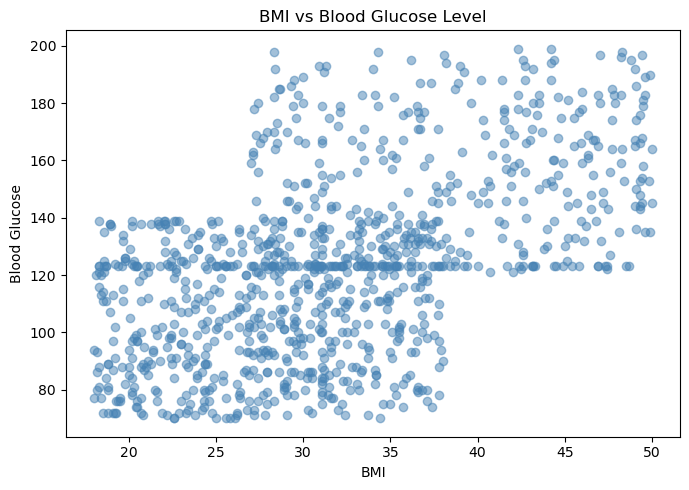

In [2]:
# Q1: A medical researcher wants to determine whether higher BMI is associated with higher blood glucose levels.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['BMI'], df['Glucose'], alpha=0.5, color='steelblue')
plt.title('BMI vs Blood Glucose Level')
plt.xlabel('BMI')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

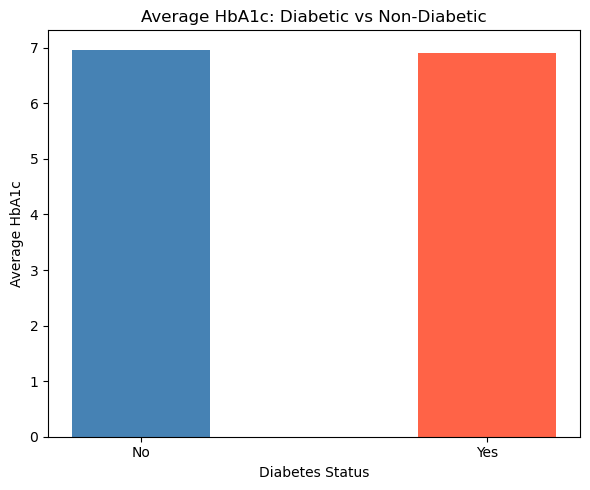

In [3]:
# Q2: The diabetes clinic wants to compare average HbA1c levels between diabetic and non-diabetic patients.
# Chart: Bar Chart
avg_hba1c = df.groupby('Outcome')['HbA1c'].mean()
plt.figure(figsize=(6, 5))
plt.bar(avg_hba1c.index, avg_hba1c.values, color=['steelblue', 'tomato'], width=0.4)
plt.title('Average HbA1c: Diabetic vs Non-Diabetic')
plt.xlabel('Diabetes Status')
plt.ylabel('Average HbA1c')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\1143278524.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby('Month')['Glucose'].mean()


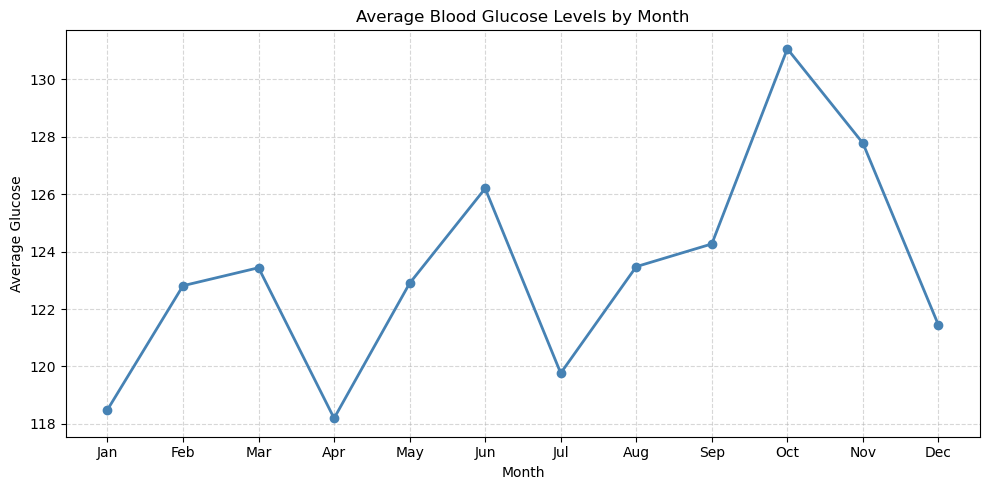

In [4]:
# Q3: Doctors want to track average blood glucose levels month by month.
# Chart: Line Chart
monthly_avg = df.groupby('Month')['Glucose'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='steelblue', linewidth=2)
plt.title('Average Blood Glucose Levels by Month')
plt.xlabel('Month')
plt.ylabel('Average Glucose')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\2364043522.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_diabetic, diabetic], labels=['No', 'Yes'])


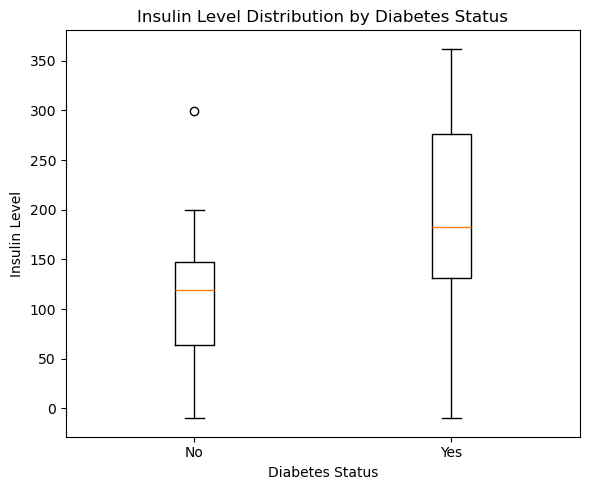

In [5]:
# Q4: Researchers suspect a few diabetic patients have extremely high insulin levels compared to others.
# Chart: Box Plot
diabetic = df[df['Outcome'] == 'Yes']['Insulin']
non_diabetic = df[df['Outcome'] == 'No']['Insulin']
plt.figure(figsize=(6, 5))
plt.boxplot([non_diabetic, diabetic], labels=['No', 'Yes'])
plt.title('Insulin Level Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Insulin Level')
plt.tight_layout()
plt.show()

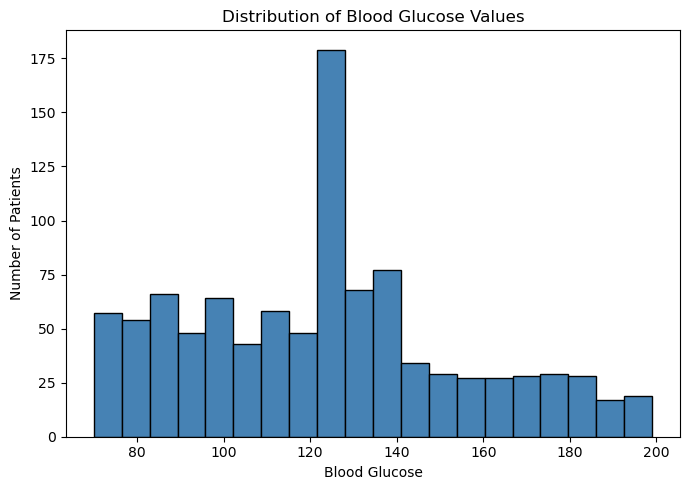

In [6]:
# Q5: The clinic wants to understand how blood glucose values are distributed among patients.
# Chart: Histogram
plt.figure(figsize=(7, 5))
plt.hist(df['Glucose'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Blood Glucose Values')
plt.xlabel('Blood Glucose')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

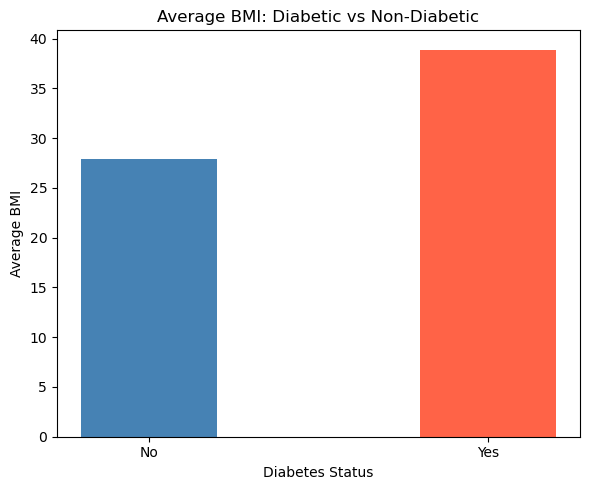

In [7]:
# Q6: A physician wants to compare average BMI between diabetic and non-diabetic groups.
# Chart: Bar Chart
avg_bmi = df.groupby('Outcome')['BMI'].mean()
plt.figure(figsize=(6, 5))
plt.bar(avg_bmi.index, avg_bmi.values, color=['steelblue', 'tomato'], width=0.4)
plt.title('Average BMI: Diabetic vs Non-Diabetic')
plt.xlabel('Diabetes Status')
plt.ylabel('Average BMI')
plt.tight_layout()
plt.show()

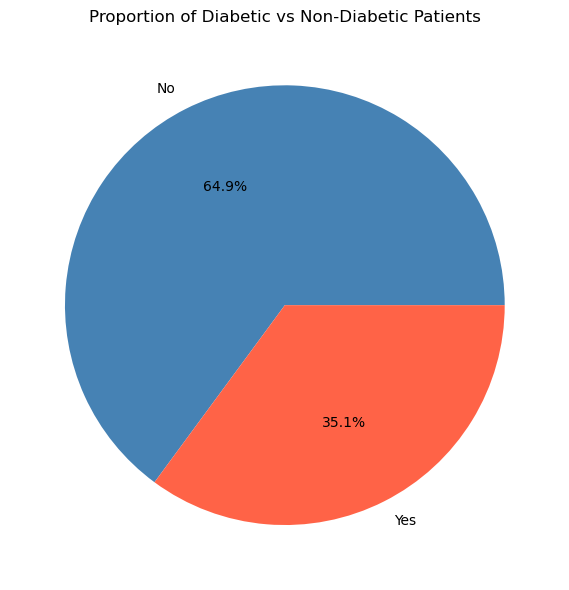

In [8]:
# Q7: The hospital wants to show the proportion of diabetic versus non-diabetic patients.
# Chart: Pie Chart
counts = df['Outcome'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
plt.title('Proportion of Diabetic vs Non-Diabetic Patients')
plt.tight_layout()
plt.show()

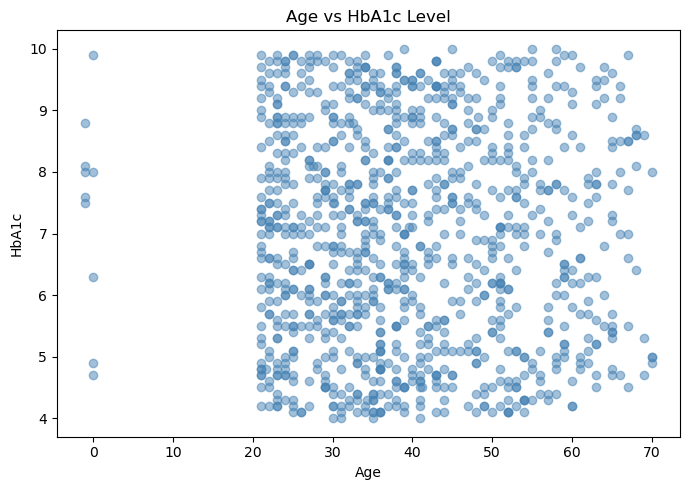

In [9]:
# Q8: Researchers want to determine whether age is related to HbA1c levels.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['HbA1c'], alpha=0.5, color='steelblue')
plt.title('Age vs HbA1c Level')
plt.xlabel('Age')
plt.ylabel('HbA1c')
plt.tight_layout()
plt.show()

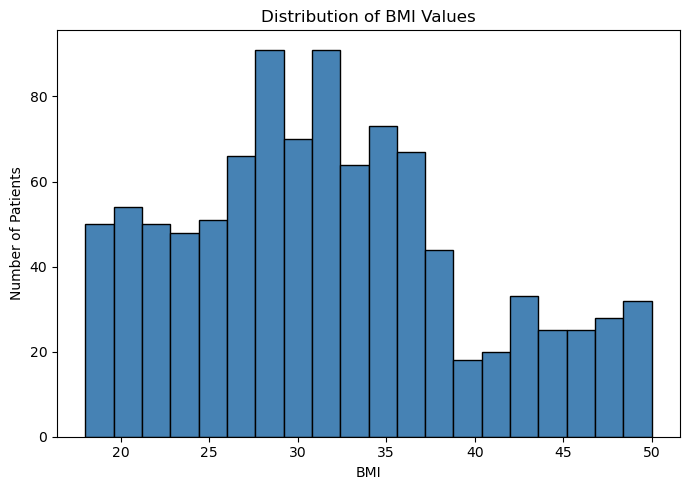

In [10]:
# Q9: Doctors want to see whether most patients have normal BMI values or whether obesity is common.
# Chart: Histogram
plt.figure(figsize=(7, 5))
plt.hist(df['BMI'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of BMI Values')
plt.xlabel('BMI')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\161744380.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_glucose = df.groupby('AgeGroup')['Glucose'].mean()


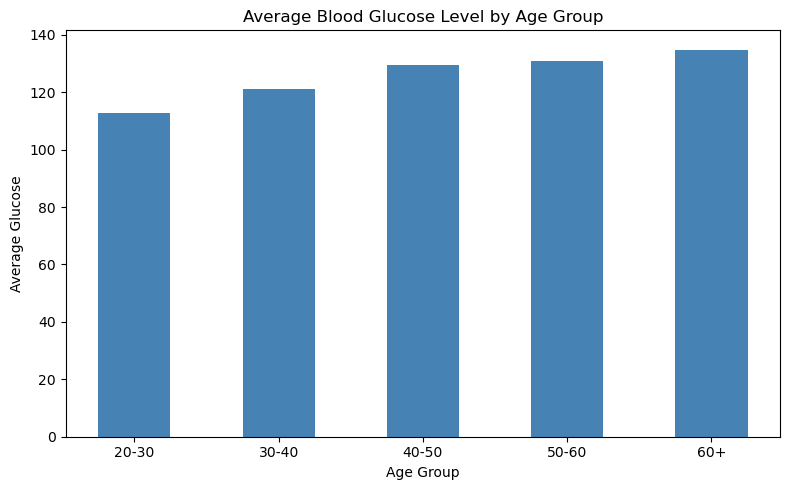

In [11]:
# Q10: A healthcare analyst wants to identify the age group with the highest average blood glucose level.
# Chart: Bar Chart
avg_glucose = df.groupby('AgeGroup')['Glucose'].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_glucose.index, avg_glucose.values, color='steelblue', width=0.5)
plt.title('Average Blood Glucose Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Glucose')
plt.tight_layout()
plt.show()

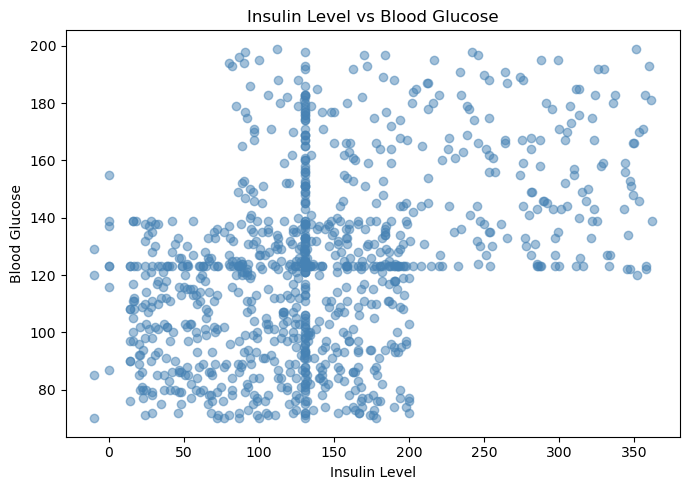

In [12]:
# Q11: Researchers suspect higher insulin levels correspond to lower glucose values.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['Insulin'], df['Glucose'], alpha=0.5, color='steelblue')
plt.title('Insulin Level vs Blood Glucose')
plt.xlabel('Insulin Level')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

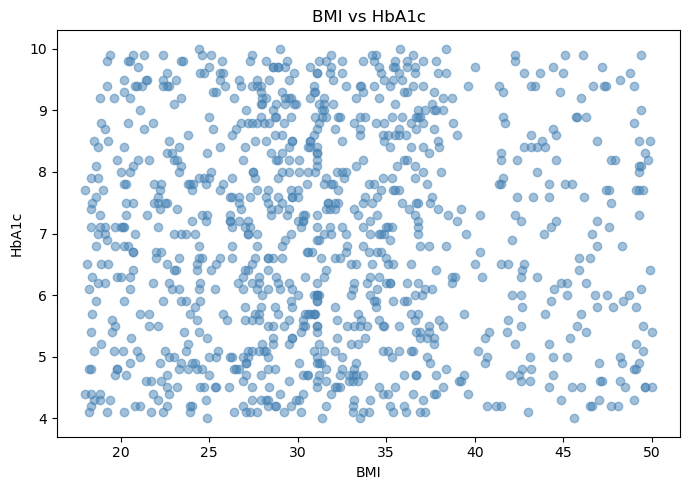

In [13]:
# Q12: A diabetes specialist wants to study the relationship between BMI and HbA1c.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['BMI'], df['HbA1c'], alpha=0.5, color='steelblue')
plt.title('BMI vs HbA1c')
plt.xlabel('BMI')
plt.ylabel('HbA1c')
plt.tight_layout()
plt.show()

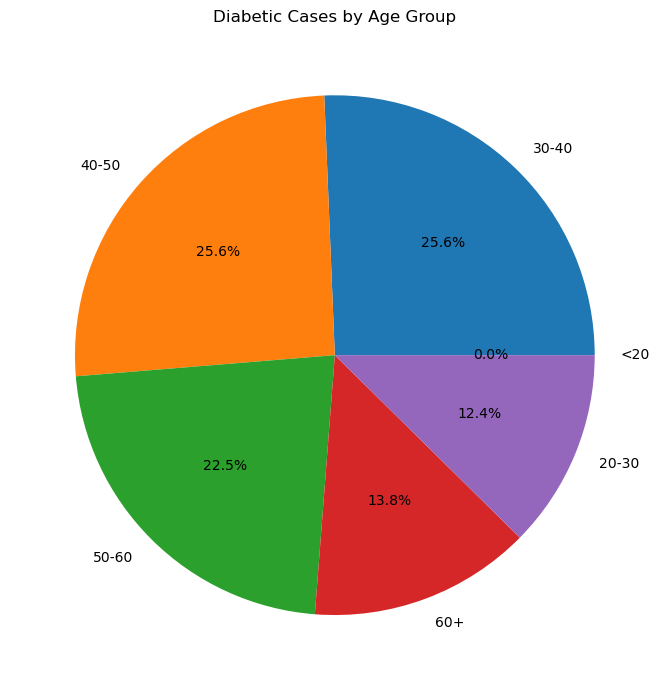

In [14]:
# Q13: The hospital wants to display each age group's contribution to total diabetic cases.
# Chart: Pie Chart
diabetic_age = df[df['Outcome'] == 'Yes']['AgeGroup'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(diabetic_age.values, labels=diabetic_age.index, autopct='%1.1f%%')
plt.title('Diabetic Cases by Age Group')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\2518328859.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_hba1c = df6.groupby('Month')['HbA1c'].mean()


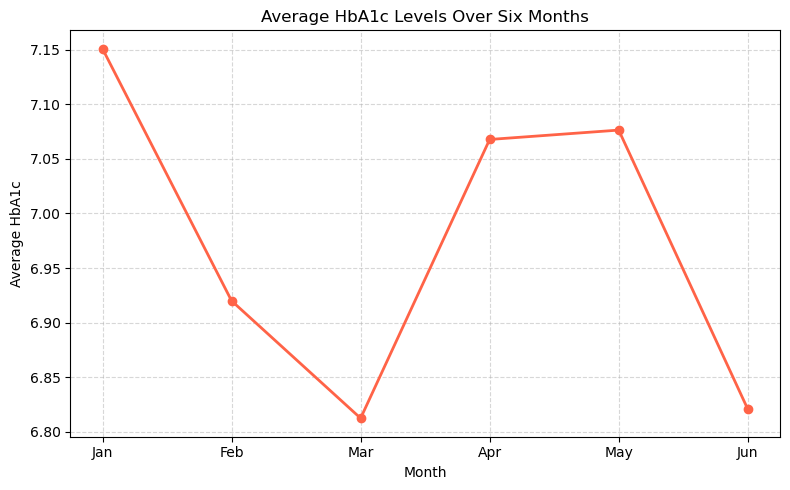

In [15]:
# Q14: Doctors want to track average HbA1c levels over six months.
# Chart: Line Chart
six_months = ['Jan','Feb','Mar','Apr','May','Jun']
df6 = df[df['Month'].isin(six_months)]
monthly_hba1c = df6.groupby('Month')['HbA1c'].mean()
plt.figure(figsize=(8, 5))
plt.plot(monthly_hba1c.index, monthly_hba1c.values, marker='o', color='tomato', linewidth=2)
plt.title('Average HbA1c Levels Over Six Months')
plt.xlabel('Month')
plt.ylabel('Average HbA1c')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

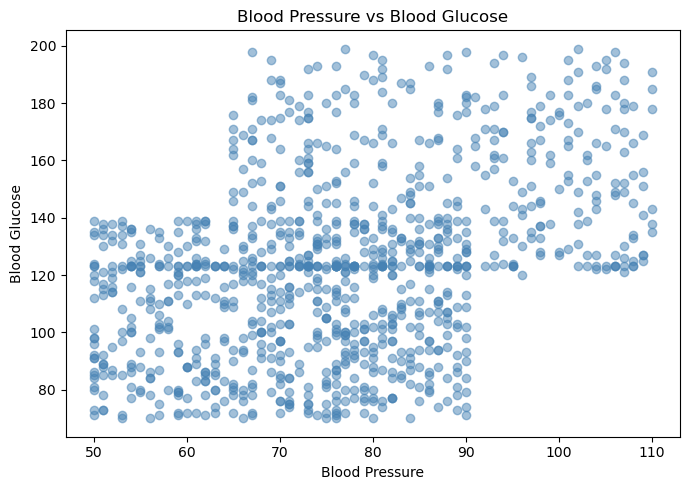

In [16]:
# Q15: Researchers want to examine whether higher blood pressure is associated with higher glucose levels.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['BloodPressure'], df['Glucose'], alpha=0.5, color='steelblue')
plt.title('Blood Pressure vs Blood Glucose')
plt.xlabel('Blood Pressure')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

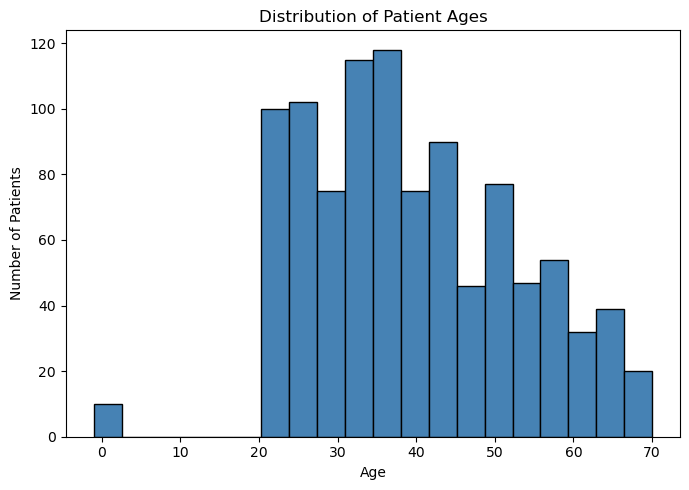

In [17]:
# Q16: The clinic wants to visualize the distribution of patient ages.
# Chart: Histogram
plt.figure(figsize=(7, 5))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

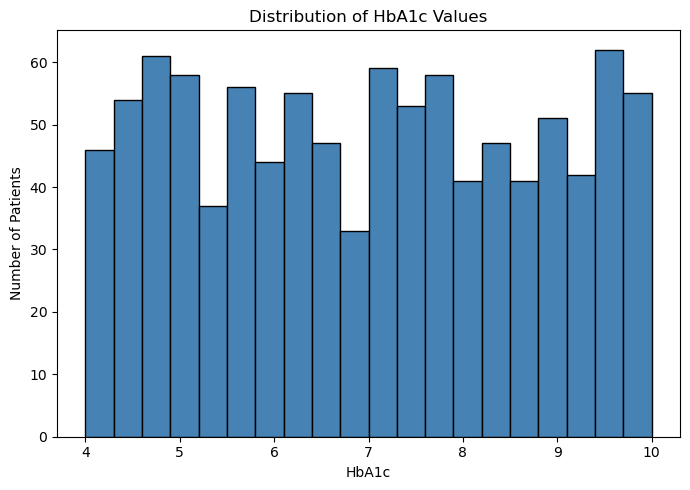

In [18]:
# Q17: Healthcare analysts want to understand how HbA1c values are distributed among all patients.
# Chart: Histogram
plt.figure(figsize=(7, 5))
plt.hist(df['HbA1c'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of HbA1c Values')
plt.xlabel('HbA1c')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

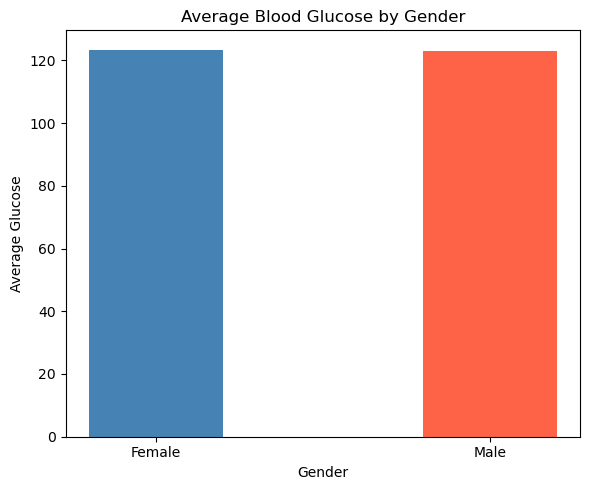

In [19]:
# Q18: Researchers want to compare average blood glucose levels for males and females.
# Chart: Bar Chart
avg_glucose_gender = df.groupby('Gender')['Glucose'].mean()
plt.figure(figsize=(6, 5))
plt.bar(avg_glucose_gender.index, avg_glucose_gender.values, color=['steelblue', 'tomato'], width=0.4)
plt.title('Average Blood Glucose by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Glucose')
plt.tight_layout()
plt.show()

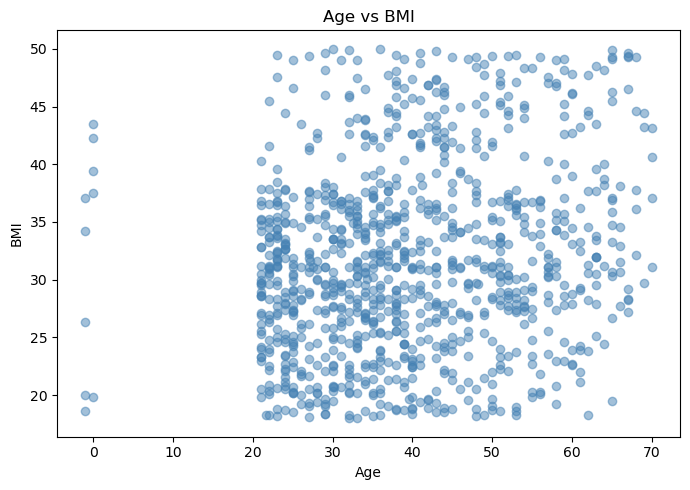

In [20]:
# Q19: Doctors want to determine whether older patients tend to have higher BMI values.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['BMI'], alpha=0.5, color='steelblue')
plt.title('Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

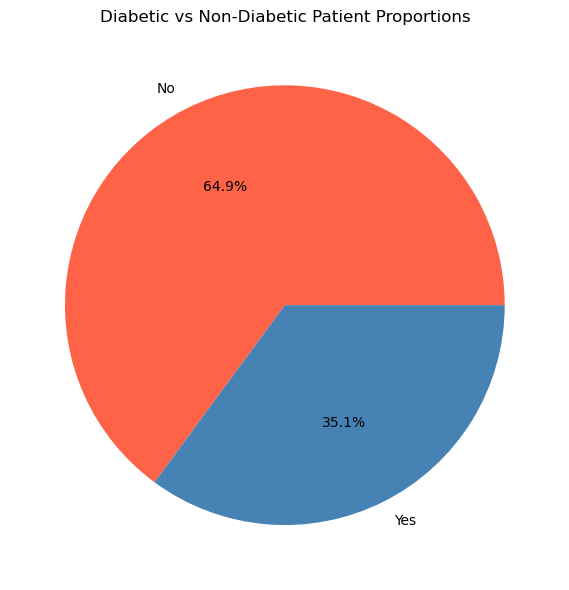

In [21]:
# Q20: The hospital wants a quick overview of diabetic versus non-diabetic patient proportions.
# Chart: Pie Chart
counts = df['Outcome'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['tomato', 'steelblue'])
plt.title('Diabetic vs Non-Diabetic Patient Proportions')
plt.tight_layout()
plt.show()

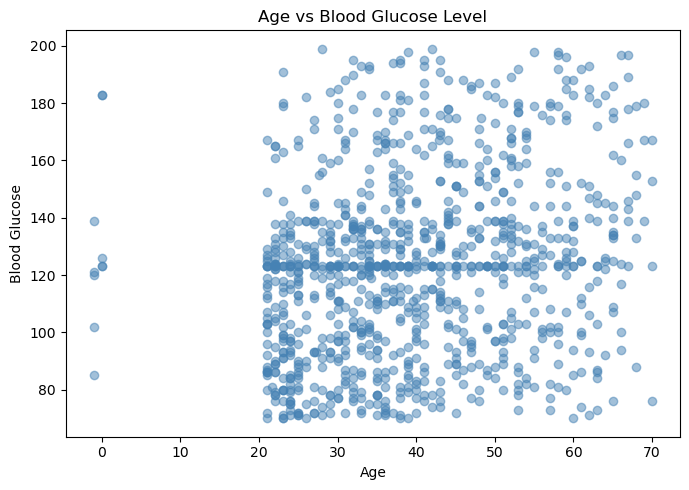

In [22]:
# Q21: Researchers want to study whether age influences blood glucose levels.
# Chart: Scatter Plot
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Glucose'], alpha=0.5, color='steelblue')
plt.title('Age vs Blood Glucose Level')
plt.xlabel('Age')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\3660752746.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bp = df.groupby('AgeGroup')['BloodPressure'].mean()


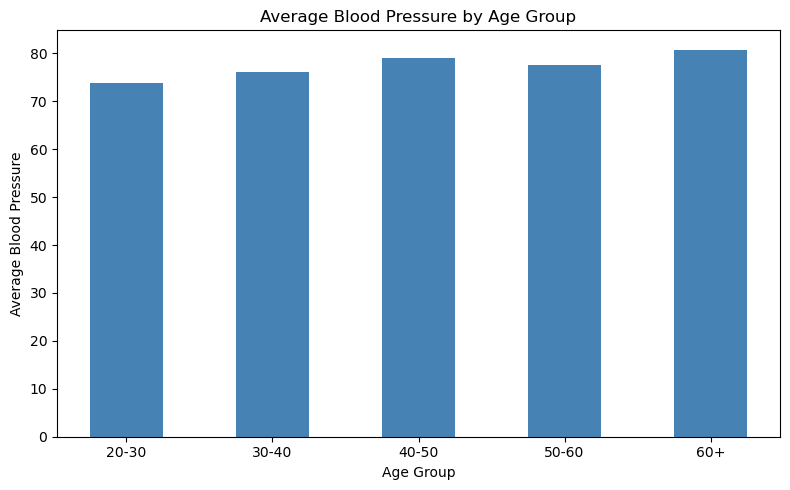

In [23]:
# Q22: The clinic wants to compare average blood pressure across age groups.
# Chart: Bar Chart
avg_bp = df.groupby('AgeGroup')['BloodPressure'].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_bp.index, avg_bp.values, color='steelblue', width=0.5)
plt.title('Average Blood Pressure by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Blood Pressure')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\833040718.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_diabetic_glucose, diabetic_glucose], labels=['No', 'Yes'])


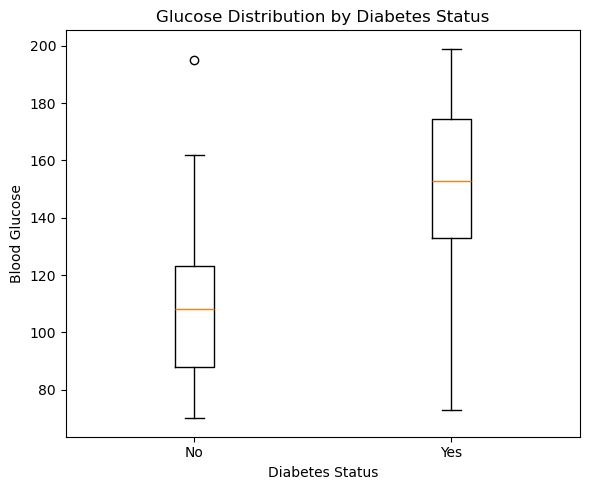

In [24]:
# Q23: Doctors want to compare glucose distributions between diabetic and non-diabetic patients, including outliers.
# Chart: Box Plot
diabetic_glucose = df[df['Outcome'] == 'Yes']['Glucose']
non_diabetic_glucose = df[df['Outcome'] == 'No']['Glucose']
plt.figure(figsize=(6, 5))
plt.boxplot([non_diabetic_glucose, diabetic_glucose], labels=['No', 'Yes'])
plt.title('Glucose Distribution by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\3786633995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_insulin = df.groupby('AgeGroup')['Insulin'].mean()


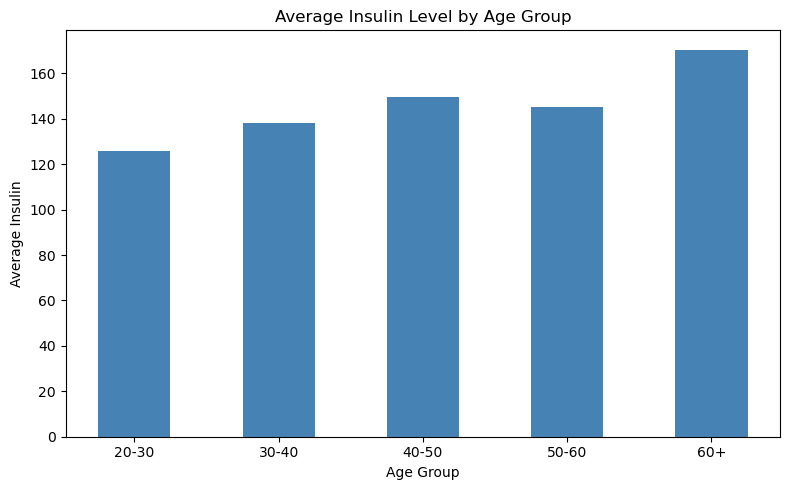

In [25]:
# Q24: Researchers want to compare average insulin levels across age groups.
# Chart: Bar Chart
avg_insulin = df.groupby('AgeGroup')['Insulin'].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_insulin.index, avg_insulin.values, color='steelblue', width=0.5)
plt.title('Average Insulin Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Insulin')
plt.tight_layout()
plt.show()

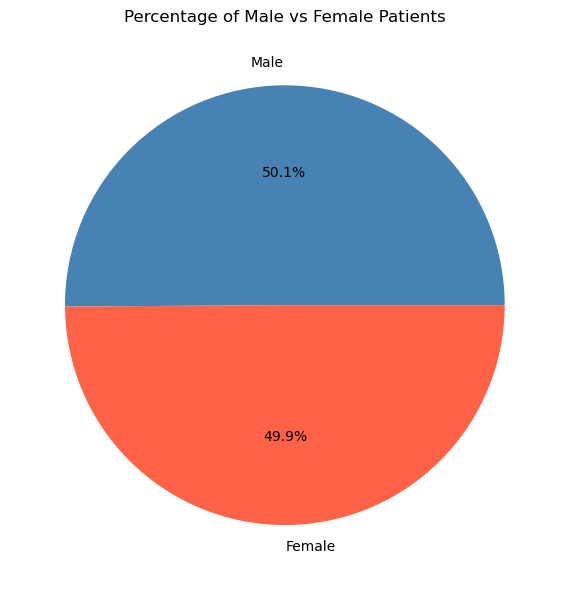

In [26]:
# Q25: Hospital management wants to show the percentage of male and female patients.
# Chart: Pie Chart
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['steelblue', 'tomato'])
plt.title('Percentage of Male vs Female Patients')
plt.tight_layout()
plt.show()

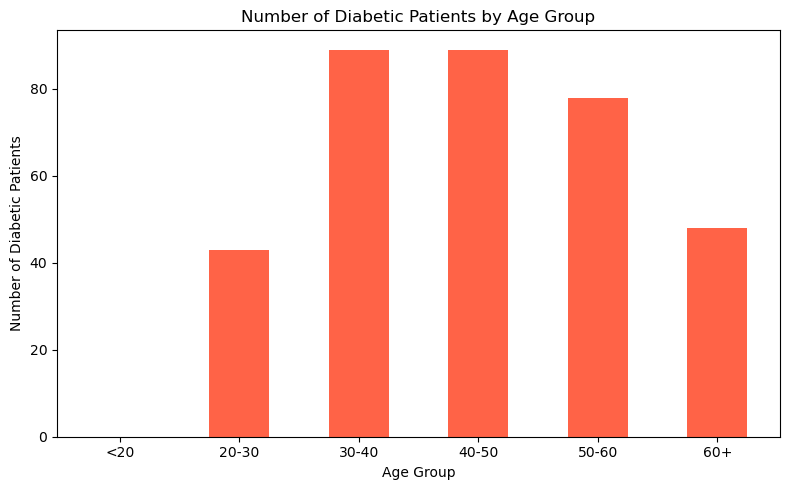

In [27]:
# Q26: Doctors want to compare the number of diabetic patients across age groups.
# Chart: Bar Chart
diabetic_counts = df[df['Outcome'] == 'Yes']['AgeGroup'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(diabetic_counts.index, diabetic_counts.values, color='tomato', width=0.5)
plt.title('Number of Diabetic Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Diabetic Patients')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\966736222.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_hba1c_age = df.groupby('AgeGroup')['HbA1c'].mean()


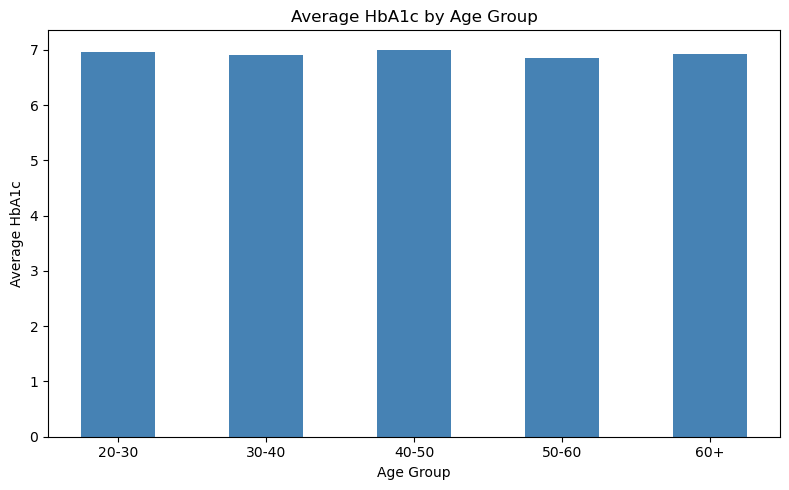

In [28]:
# Q27: Researchers want to compare average HbA1c values across age categories.
# Chart: Bar Chart
avg_hba1c_age = df.groupby('AgeGroup')['HbA1c'].mean()
plt.figure(figsize=(8, 5))
plt.bar(avg_hba1c_age.index, avg_hba1c_age.values, color='steelblue', width=0.5)
plt.title('Average HbA1c by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average HbA1c')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\3014293550.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(age_group_data, labels=labels)


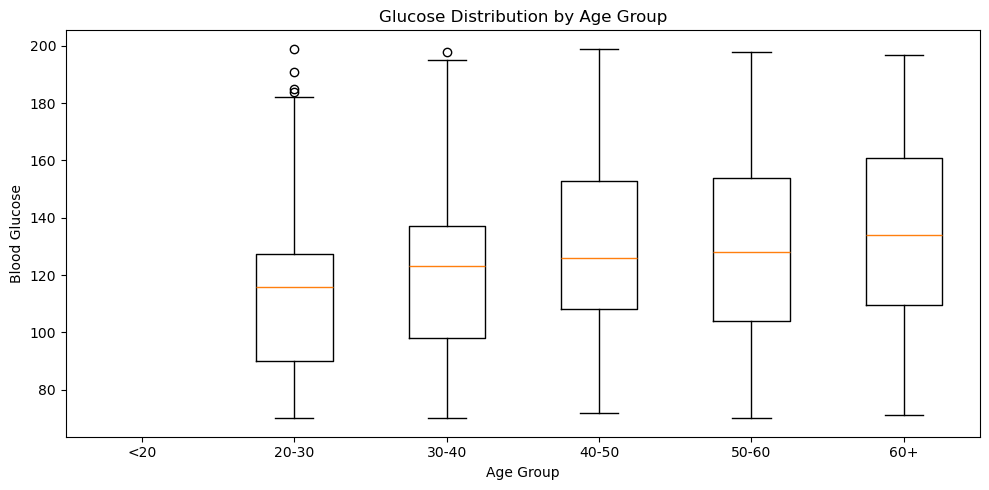

In [29]:
# Q28: The clinic suspects extreme glucose values occur in some age groups.
# Chart: Box Plot
age_group_data = [df[df['AgeGroup'] == g]['Glucose'].values for g in labels]
plt.figure(figsize=(10, 5))
plt.boxplot(age_group_data, labels=labels)
plt.title('Glucose Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Blood Glucose')
plt.tight_layout()
plt.show()

C:\Users\susha\AppData\Local\Temp\ipykernel_21796\489512524.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_glucose = df.groupby('Month')['Glucose'].mean()


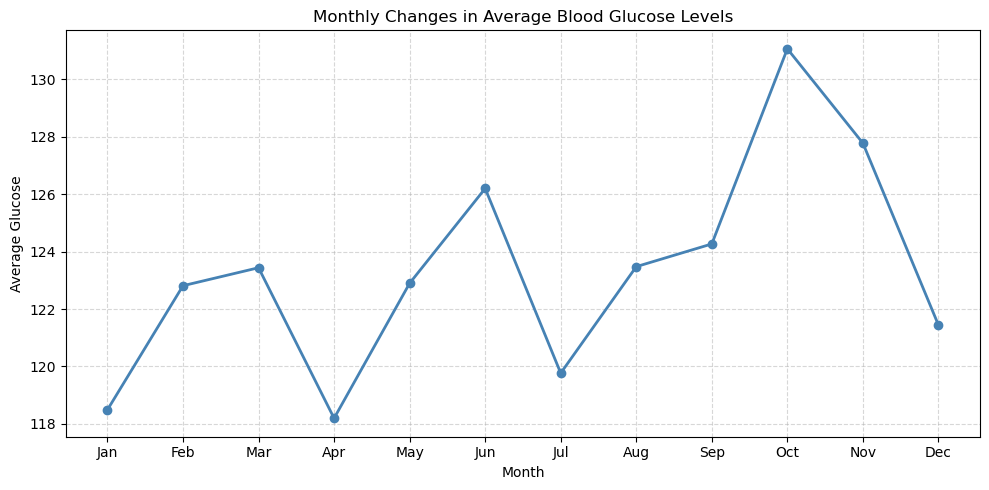

In [30]:
# Q29: Researchers want to examine monthly changes in average blood glucose levels.
# Chart: Line Chart
monthly_glucose = df.groupby('Month')['Glucose'].mean()
plt.figure(figsize=(10, 5))
plt.plot(monthly_glucose.index, monthly_glucose.values, marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Changes in Average Blood Glucose Levels')
plt.xlabel('Month')
plt.ylabel('Average Glucose')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

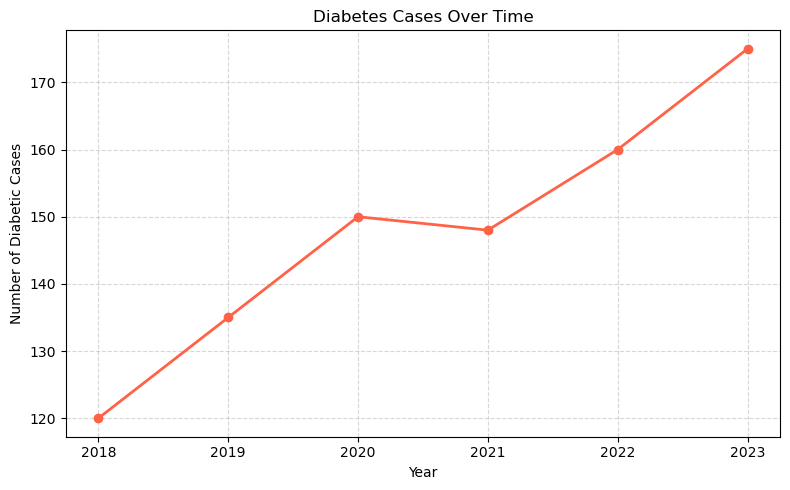

In [31]:
# Q30: Doctors want to observe whether diabetes cases increased or decreased over time.
# Chart: Line Chart
np.random.seed(0)
years = [2018, 2019, 2020, 2021, 2022, 2023]
cases = [120, 135, 150, 148, 160, 175]
plt.figure(figsize=(8, 5))
plt.plot(years, cases, marker='o', color='tomato', linewidth=2)
plt.title('Diabetes Cases Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Diabetic Cases')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()